WARNING  | D22-01-2026 T18:31:48 | ml\dataclass_detector.py: def create_data(): line - 160 В наборе данных 1539 размеченных изображений


<class 'tuple'>
torch.Size([63, 4])
torch.Size([1, 640, 640])


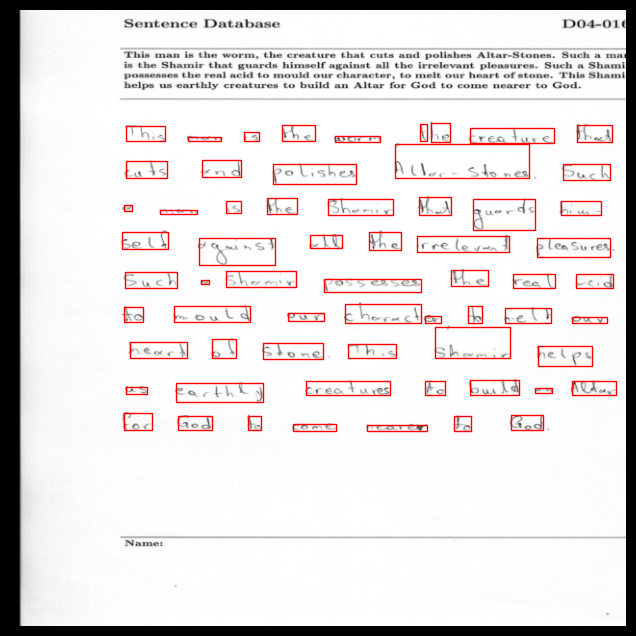

In [3]:
from ml.config import WORKDIR
from ml.dataclass_detector import OCRDetectorDataset
from ml.utils import visualize_bboxes

new_layout = OCRDetectorDataset(WORKDIR / 'dataset' / 'iam-form', 'train')

pred = new_layout[465]
print(f'{type(pred)}')
print(pred[1]['boxes'].shape)
print(pred[0].shape)
visualize_bboxes(pred[0], pred[1]['boxes'])

## Проверка новой лосс функции | Не используется!!!

#### Заменить настоящие bbox_ciou и dfl_decode для лосс функции-класса на время теста!!!

In [ ]:
import torch


def dfl_decode(pred_dist, reg_max):
    """
    pred_dist: [B, N, 4 * reg_max]
    return:    [B, N, 4] (xyxy)
    """
    B, N, _ = pred_dist.shape
    pred_dist = pred_dist.view(B, N, 4, reg_max)
    prob = pred_dist.softmax(-1)

    proj = torch.arange(reg_max, device=pred_dist.device, dtype=prob.dtype)
    dist = (prob * proj).sum(-1)

    # pretend anchors at (0,0) with unit scale (test only)
    x1 = -dist[..., 0]
    y1 = -dist[..., 1]
    x2 = dist[..., 2]
    y2 = dist[..., 3]

    return torch.stack([x1, y1, x2, y2], dim=-1)


def bbox_ciou(boxes1, boxes2, eps=1e-7):
    """
    boxes1: [N, 4]
    boxes2: [M, 4]
    """
    b1 = boxes1.unsqueeze(1)
    b2 = boxes2.unsqueeze(0)

    # Intersection
    inter = (
        torch.min(b1[..., 2:], b2[..., 2:]) -
        torch.max(b1[..., :2], b2[..., :2])
    ).clamp(min=0)

    inter_area = inter[..., 0] * inter[..., 1]

    # Union
    area1 = (b1[..., 2] - b1[..., 0]) * (b1[..., 3] - b1[..., 1])
    area2 = (b2[..., 2] - b2[..., 0]) * (b2[..., 3] - b2[..., 1])
    union = area1 + area2 - inter_area + eps

    iou = inter_area / union

    # Center distance
    c1 = (b1[..., :2] + b1[..., 2:]) / 2
    c2 = (b2[..., :2] + b2[..., 2:]) / 2
    center_dist = ((c1 - c2) ** 2).sum(-1)

    # Enclosing box
    enclose_lt = torch.min(b1[..., :2], b2[..., :2])
    enclose_rb = torch.max(b1[..., 2:], b2[..., 2:])
    enclose_wh = (enclose_rb - enclose_lt).clamp(min=0)
    c2_diag = (enclose_wh ** 2).sum(-1) + eps

    return iou - center_dist / c2_diag


#### Тестовый прогон | Не понадобилась, была удалена. Утвердил встроенную функцию потерь

In [28]:
import torch
from ml.loss_function.loss import OCRYOLOv8Loss

B = 2          # batch
N = 100        # predictions
reg_max = 16

# Fake predictions
preds = {
    "boxes": torch.randn(B, N, 4 * reg_max, requires_grad=True),
    "scores": torch.randn(B, N, requires_grad=True),
}

# Fake targets: по 1–2 GT на изображение
targets = [
    torch.tensor([[ -1.0, -1.0,  1.0,  1.0 ]]),              # 1 объект
    torch.tensor([[ -0.5, -0.5,  0.5,  0.5 ],
                  [ -1.5, -1.5, -0.5, -0.5 ]])               # 2 объекта
]
loss_fn = OCRYOLOv8Loss(
    box_weight=7.5,
    obj_weight=1.0,
    topk=10
)

loss, loss_dict = loss_fn(preds, targets)

print("Total loss:", loss.item())
print("Loss components:", loss_dict)


"Проверяем Распространение ошибки"
loss.backward()

print("Grad boxes:", preds["boxes"].grad.abs().mean().item())
print("Grad scores:", preds["scores"].grad.abs().mean().item())

"Проверяем TAL работоспособность"
with torch.no_grad():
    preds_good = preds.copy()
    preds_good["boxes"] *= 0.1
    loss_good, _ = loss_fn(preds_good, targets)

print("Loss original:", loss.item())
print("Loss better preds:", loss_good.item())


Total loss: 8.17934799194336
Loss components: {'box': tensor(1.9744), 'obj': tensor(1.5505)}
Grad pred_dist: 1.3281882274895906e-05
Grad scores: 0.002431822009384632
Loss original: 8.17934799194336
Loss better preds: 8.196824073791504


#### Меньше лосс -> меньше градиенты = хороший знак!